# Final Exam (part 1) - Computational Physics 2

### Deadline: Friday 6 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.


## 1. Finite-difference method for quantum mechanics: Wave packets in a Parabolic Potential

Consider a quantum mechanical particle of mass $m$ constrained to move along the x-axis. Its dynamics are governed by the **time-dependent Schrödinger equation**:

$$i\hbar \frac{\partial \Psi(x,t)}{\partial t} = -\frac{\hbar^2}{2m} \frac{\partial^2 \Psi(x,t)}{\partial x^2} + V(x) \Psi(x,t)$$

where $\Psi(x,t)$ represents the quantum state of the particle, $\hbar$ is the reduced Planck constant, $m$ is the mass of the particle, and $V(x) = \frac{1}{2} m \omega^2 x^2$ is the one-dimensional quantum harmonic oscillator potential with $\omega$ representing the angular frequency of the oscillator.

### Initial Conditions:

At time $t=0$, you will explore two different initial wavefunctions for the particle:

1.  **Single Gaussian Wave Packet:** A localized wave packet with an initial momentum:

$$\Psi(x,0) = A e^{-\frac{(x-x_0)^2}{2\sigma^2}} e^{i p_0 x / \hbar}$$

where $x_0$ is the initial position, $\sigma$ is the width, and $p_0$ is the initial momentum. $A$ is a normalization constant.

2.  **Superposition of Two Gaussian Wave Packets:** It is formed by the sum of two distinct Gaussian wave packets:

$$\Psi(x,0) = A_1 e^{-\frac{(x-x_{0,1})^2}{2\sigma_1^2}} e^{i p_{0,1} x / \hbar} + A_2 e^{-\frac{(x-x_{0,2})^2}{2\sigma_2^2}} e^{i p_{0,2} x / \hbar}$$

where $x_{0,k}$ are initial positions, $\sigma_k$ are widths, $p_{0,k}$ are initial momenta for each packet, and $A_k$ are constants adjusted such that the total wavefunction $\Psi(x,0)$ is **normalised**, meaning $\int_{-\infty}^{\infty} |\Psi(x,0)|^2 dx = 1$.

### Boundary Conditions:

You will simulate the particle in a finite spatial domain, $[-L_x/2, L_x/2]$. At the boundaries of this domain, we will apply **Dirichlet boundary conditions**, meaning the wavefunction is identically zero: $\Psi(-L_x/2, t) = \Psi(L_x/2, t) = 0$.

### Tasks

Your goal is to develop and implement a numerical algorithm to solve the time-dependent Schrödinger equation using the **Crank-Nicolson method** that we reviewed in class:

#### (a) Mathematical derivation:

In a markdown cell, derive the discrete form of the time-dependent Schrödinger equation using the **Crank-Nicolson method**.

- Begin by discretising the spatial domain ($x_j = j \Delta x$) and time ($t_n = n \Delta t$).

- Use a central finite difference approximation for the second spatial derivative. Your derivation should lead to a matrix equation of the form $\mathbf{A} \Psi^{n+1} = \mathbf{B} \Psi^n$, where $\Psi^{n+1}$ and $\Psi^n$ are vectors of the wavefunction at interior grid points.

- Clearly define the elements of the tridiagonal matrices $\mathbf{A}$ and $\mathbf{B}$ in terms of $\hbar$, $m$, $\Delta x$, $\Delta t$, and $V_j$.

- Show how the discrete Hamiltonian operator $\mathbf{H}$ is represented within these matrices.




$$ i \hbar \frac{\partial \Psi(x, t)}{\partial t}=-\frac{\hbar^2}{2 m} \cdot \frac{\partial^2 \Psi(x, t)}{\partial x^2}+V(x) \Psi(x, t)$$

$$ i \hbar \frac{\partial \psi(x, t)}{\partial t}=-\frac{\hbar^2}{2 m} \frac{\partial^2 \psi(x, t)}{\partial x^2}+\frac{1}{2} m \omega^2 x^2 \psi(x, t)$$



$$ i \hbar\left[\frac{\psi_j^{n+1}-\psi_j^n}{\Delta t}\right]=\frac{-\hbar^2}{4 m}\left[\frac{\psi_{j+1}^n-2 \psi_j^n+\psi_{j-1}^n}{\Delta x^2}+\frac{\psi_{j+1}^{n+1}-2 \psi_j^{n+1}+\psi_{j-1}^{n+1}}{\Delta x^2}\right]+\frac{1}{2} m \omega^2 j \Delta x^2 \psi_j^n $$


$$\frac{\hbar^2}{4 m \Delta x^2} \psi_{j+1}^{n+1}-\left(\frac{i \hbar}{\Delta t}-\frac{\hbar^2}{2 m \Delta x^2}\right) \psi_j^{n+1}+\frac{\hbar^2}{4 m \Delta x^2} \psi_{j-1}^{n+1}=\frac{-\hbar^2}{4 m \Delta x^2} \psi_{i+1}^n+\left(\frac{i \hbar}{\Delta t}+\frac{\hbar^2}{2 m \Delta x^2}+\frac{1}{2} m \omega^2 j^2 \Delta x^2\right) \psi_j^n-\frac{\hbar^2}{4 m \Delta x^2} \psi_{j-1}^n$$


$$
\left[\begin{array}{ccccccc}
\frac{i \hbar}{\Delta t}-2r & r & 0 & 0 & \cdots & 0 \\
r & \frac{i \hbar}{\Delta t}-2r & r & 0 & \cdots & \vdots \\
0 & r & \frac{i \hbar}{\Delta t}-2r & r & \cdots & \vdots \\
\vdots & \cdots & \cdots & \cdots & \cdots & \vdots \\
\vdots & \cdots & 0 & r & \frac{i \hbar}{\Delta t}-2r & r \\
0 & 0 & 0 & 0 & r & \frac{i \hbar}{\Delta t}-2r
\end{array}\right]

\left[\begin{array}{c}\psi_1^{n+1} \\
\psi_2^{n+1} \\
\vdots \\
\psi_J^{n+1}
\end{array}\right]

=

\left[\begin{array}{ccccc}
\frac{i \hbar}{\Delta t}-H_1 & -r & 0 & \cdots & 0 \\
-r & \frac{i \hbar}{\Delta t}-H_2 & -r & 0 & \\
0 & -r & \frac{i \hbar}{\Delta t}-H_3 & -r & 0 \\
\vdots & \cdots & \cdots & \cdots & \vdots \\
\vdots & \cdots & -r & \frac{i \hbar}{\Delta t}-H_{J-1} & -r \\
0 & \cdots & 0 & -r & \frac{i \hbar}{\Delta t}-H_J 
\end{array}\right]

\left[\begin{array}{c}\psi_1^{n} \\
\psi_2^{n} \\
\vdots \\
\psi_J^{n}
\end{array}\right]
$$

Where $r=\frac{\hbar^2}{4 m \Delta x^2}$ and $H_j=-\frac{\hbar^2}{2 m \Delta x^2}-\frac{1}{2} m \omega^2 j² \Delta x^2$. Then,

$$
A \Psi^{n+1} = B \Psi^n
$$



Aditionally, here is the calculation of the normalisation constant $A$, $A_1,$ and $A_2$ for the initial wavefunction:

1.  **Single Gaussian Wave Packet:** A localized wave packet with an initial momentum:

$$
\begin{aligned}
& \int_{-\infty}^{\infty}|\psi(x, 0)|^2 d x=1 \\
& \int_{-\infty}^{\infty} A^2 e^{-\frac{\left(x-x_0\right)^2}{\sigma^2}} d x=1 \\
& A^2\left(\sqrt{\sigma^2 \pi}\right)=1 \\
& A^2=\frac{1}{\sigma \sqrt{\pi}} \\
& A=\frac{1}{\sqrt[4]{\pi} \sqrt{\sigma}}
\end{aligned}
$$

2.  **Superposition of Two Gaussian Wave Packets:** 

$$
\begin{aligned}
& \int_{-\infty}^{\infty}|\psi(x, 0)|^2 d x=1 \\
& \int_{-\infty}^{\infty}\left[A_1^2 e^{-\frac{\left(x-x_{0,1}\right)^2}{\sigma_1^2}+A_2^2} e^{-\frac{\left(x-x_{0,2}\right)^2}{\sigma_2^2}}\right] d x=1 \\
& A_1^2 \sqrt{\sigma_1^2 \pi}+A_2^2 \sqrt{\sigma_2^2 \pi}=1 \\
& A_1^2 \sigma_1+A_2^2 \sigma_2=\frac{1}{\sqrt{\pi}}
\end{aligned}
$$

We can set $A_1^2=\frac{1}{2 \sigma_1 \sqrt{\pi}}$, so that

$$
\begin{aligned}
& A_2^2 \sigma_2=\frac{1}{\sqrt{\pi}}\left(1-\frac{1}{2}\right) \\
& A_2^2=\frac{1}{2 \sqrt{\pi}} \sigma_2
\end{aligned}
$$



#### (b) Python code implementation:

Use **python classes** to implement the numerical solution to the time-dependent Schrödinger equation. You will need to:

- Set up the physical constants, simulation parameters, spatial and temporal grids, and the potential. The simulation should be conducted using atomic units, where $\hbar = 1$ and $m = 1$. This simplifies the equations without loss of generality.

- Implement the initial conditions described above ensuring the proper normalisation of the initial wavefunctions. Remember that the wavefunction $\Psi$ is complex, so you should ensure that all calculations involving $\Psi$ handle complex numbers correctly.

- Construct the tridiagonal matrices $\mathbf{A}$ and $\mathbf{B}$ based on your derivations. Pay close attention to the boundary conditions. **Hint:** Use sparse matrices for computational efficiency.

- Implement a time evolution loop. At each time step, calculate the RHS vector $\mathbf{B} \Psi^n$. Solve the linear system $\mathbf{A} \Psi^{n+1} = (\text{RHS vector})$, and update the wavefunction array $\Psi$ for the next iteration, remembering to apply the boundary conditions.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [103]:
class SystemSolver:
    def __init__(self, w=1.0, dx=0.01, dt=0.001, lx=3.0, lt=0.1):
        # defining physical constants and parameters
        self.dx = dx
        self.dt = dt
        self.w = w
        self.r = 1/(4*dx**2)
        self.lx = lx
        self.lt = lt

        # Time and Space Vectors
        self.x = np.arange(-lx, lx + dx, dx)
        self.t = np.arange(0., lt + dt, dt)
        self.j = len(self.x)
        self.n = len(self.t)

    def set_conditions(self, ics):
        # Initial conditions
        if ics == 'gaussian':
            self.x0 = 0.0
            self.sigma = 0.1
            self.p0 = 1.0
            self.a0 = 1.0 / np.sqrt(self.sigma * np.sqrt(np.pi))
            
            psi_0 = self.a0 * np.exp(-((self.x - self.x0)**2) / (2 * self.sigma**2)) * np.exp(1j * self.p0 * self.x)
            self.ics = psi_0
            
        elif ics == 'two_gaussians':
            
            self.x0_1 = 0.5
            self.sigma_1 = 0.1
            self.p0_1 = 1.0
            self.a1 = 1.0 / np.sqrt(2 * self.sigma_1 * np.sqrt(np.pi))
            self.x0_2 = -0.5
            self.sigma_2 = 0.1
            self.p0_2 = -1.0 
            self.a2 = 1.0 / np.sqrt(2 * self.sigma_2 * np.sqrt(np.pi))
            
            psi_1 = np.exp(-((self.x - self.x0_1)**2) / (2 * self.sigma_1**2)) * np.exp(1j * self.p0_1 * self.x)
            psi_2 = np.exp(-((self.x - self.x0_2)**2) / (2 * self.sigma_2**2)) * np.exp(1j * self.p0_2 * self.x)
            psi_0 = self.a1 *psi_1 + self.a2 * psi_2
            
            self.ics = psi_0
        
        # Boundary conditions
        self.bcs = [0.+0.j, 0.+0.j]

    def initialize_solution(self):
        # initialize solution matrix
        psi = np.zeros((self.j,self.n), dtype=complex)
        psi[0, :] = self.bcs[0]
        psi[-1, :] = self.bcs[1]
        psi[:, 0] = self.ics
        self.psi = psi

    def hamiltonian(self,j):
        x_j = self.x[j]
        return - 1/(2 * self.dx**2) - self.w**2 * x_j**2 / 2
    
    def set_matrices(self):
        # interior points
        size = self.j - 2
        
        # Building A matrix
        A0 = np.diag([1j/self.dt - 2 * self.r] * size)
        A_1 = np.diag([self.r] * (size-1), -1)  
        A1 = np.diag([self.r] * (size-1), 1)   
        self.A = A0 + A_1 + A1
        print("Matrix A:\n", self.A)
        
        # Building B matrix
        h_values = np.array([self.hamiltonian(j) for j in range(1, self.j-1)])
        
        B0 = np.diag(1j/self.dt - h_values)
        B_1 = np.diag([-self.r] * (size-1), -1)  
        B1 = np.diag([-self.r] * (size-1), 1)    
        self.B = B0 + B_1 + B1
        print("Matrix B:\n", self.B)

    def solve(self):
        for j in range(0, self.n-1):
            psi_j = self.psi[1:-1, j].copy()
            rhs = self.B @ psi_j

            # append missing values
            rhs[0] -= self.r * self.bcs[0]
            rhs[-1] -= self.r * self.bcs[1]

            self.psi[1:-1, j+1] = np.linalg.solve(self.A, rhs)

        print("Final wave function:\n", self.psi)
        return self.psi
    
    def calculate_probability_density(self, psi_array):
        return np.abs(psi_array)**2
    
    def calculate_norm(self, psi_array):
        return np.sum(np.abs(psi_array)**2) * self.dx
        
    def potential(self, x):
        return 0.5 * self.w**2 * x**2   



#### (c) Simulations:

Run your code for both initial conditions. First, you should run it for the **Single Gaussian Wave Packet** and then for the **Superposition of Two Gaussian Wave Packets**. For each case, you should:

- Generate a plot showing snapshots of the probability density $|\Psi(x,t)|^2$ at several times. Include the potential $V(x)$ on the same plot (scaled appropriately for visibility).

- Create a 2D map and a 3D representation showing the evolution of the probability density $|\Psi(x,t)|^2$ as a function of both position $x$ and time $t$. This plot should capture the entire simulation duration.

- Create animated visualisation of the probability density of the wave packet evolving in time. 


In [104]:
solver1 = SystemSolver()
solver1.set_conditions('gaussian')
solver1.initialize_solution()
solver1.set_matrices()
psi1 = solver1.solve()

Matrix A:
 [[-5000.+1000.j  2500.   +0.j     0.   +0.j ...     0.   +0.j
      0.   +0.j     0.   +0.j]
 [ 2500.   +0.j -5000.+1000.j  2500.   +0.j ...     0.   +0.j
      0.   +0.j     0.   +0.j]
 [    0.   +0.j  2500.   +0.j -5000.+1000.j ...     0.   +0.j
      0.   +0.j     0.   +0.j]
 ...
 [    0.   +0.j     0.   +0.j     0.   +0.j ... -5000.+1000.j
   2500.   +0.j     0.   +0.j]
 [    0.   +0.j     0.   +0.j     0.   +0.j ...  2500.   +0.j
  -5000.+1000.j  2500.   +0.j]
 [    0.   +0.j     0.   +0.j     0.   +0.j ...     0.   +0.j
   2500.   +0.j -5000.+1000.j]]
Matrix B:
 [[ 5004.47005+1000.j -2500.        +0.j     0.        +0.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 [-2500.        +0.j  5004.4402 +1000.j -2500.        +0.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 [    0.        +0.j -2500.        +0.j  5004.41045+1000.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 ...
 [    0.        +0.j     0.        +0.j 

Final wave function:
 [[-8.68615507e-196-1.23818138e-196j  0.00000000e+000+0.00000000e+000j
   0.00000000e+000+0.00000000e+000j ...  0.00000000e+000+0.00000000e+000j
   0.00000000e+000+0.00000000e+000j  0.00000000e+000+0.00000000e+000j]
 [-1.73339805e-194-2.64801936e-195j -3.79258949e-058+4.25439415e-059j
  -4.78886388e-056+3.87241113e-056j ...  1.72941818e-003+5.60729974e-004j
   2.02135982e-003-3.90561296e-004j  1.79516100e-003-1.46352907e-003j]
 [-3.42437753e-193-5.58221525e-194j -7.41500322e-058+2.36791463e-058j
  -8.03223464e-056+9.63003471e-056j ...  3.29518318e-003+1.01729339e-003j
   3.82894856e-003-7.92730091e-004j  3.37852021e-003-2.82566945e-003j]
 ...
 [-3.42437753e-193+5.58221525e-194j -1.54764638e-057-1.05770487e-057j
  -3.01510702e-055-7.62254106e-057j ...  6.13949717e-003+2.49355738e-003j
   7.39859250e-003-9.03766223e-004j  6.79265441e-003-4.82265990e-003j]
 [-1.73339805e-194+2.64801936e-195j -6.42358371e-058-6.57324108e-058j
  -1.44525922e-055-3.24589239e-056j ...  3.

In [105]:
solver2 = SystemSolver()
solver2.set_conditions('two_gaussians')
solver2.initialize_solution()
solver2.set_matrices()
psi2 = solver2.solve()

Matrix A:
 [[-5000.+1000.j  2500.   +0.j     0.   +0.j ...     0.   +0.j
      0.   +0.j     0.   +0.j]
 [ 2500.   +0.j -5000.+1000.j  2500.   +0.j ...     0.   +0.j
      0.   +0.j     0.   +0.j]
 [    0.   +0.j  2500.   +0.j -5000.+1000.j ...     0.   +0.j
      0.   +0.j     0.   +0.j]
 ...
 [    0.   +0.j     0.   +0.j     0.   +0.j ... -5000.+1000.j
   2500.   +0.j     0.   +0.j]
 [    0.   +0.j     0.   +0.j     0.   +0.j ...  2500.   +0.j
  -5000.+1000.j  2500.   +0.j]
 [    0.   +0.j     0.   +0.j     0.   +0.j ...     0.   +0.j
   2500.   +0.j -5000.+1000.j]]
Matrix B:
 [[ 5004.47005+1000.j -2500.        +0.j     0.        +0.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 [-2500.        +0.j  5004.4402 +1000.j -2500.        +0.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 [    0.        +0.j -2500.        +0.j  5004.41045+1000.j ...
      0.        +0.j     0.        +0.j     0.        +0.j]
 ...
 [    0.        +0.j     0.        +0.j 

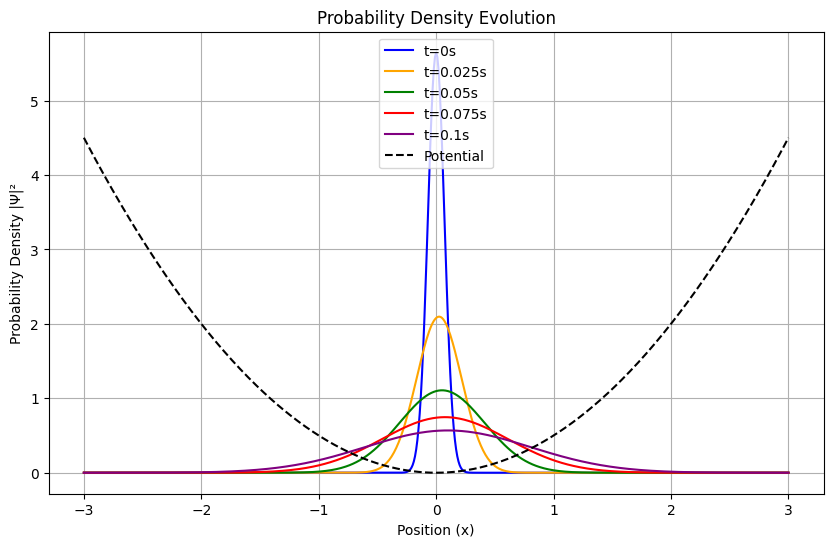

In [106]:
prob = solver1.calculate_probability_density(psi1)
norm = solver1.calculate_norm(psi1)
potential = solver1.potential(solver1.x)

plt.figure(figsize=(10, 6))
plt.plot(solver1.x, prob[:, 0], label='t=0s', color='blue')
plt.plot(solver1.x, prob[:, 25], label='t=0.025s', color='orange')
plt.plot(solver1.x, prob[:, 50], label='t=0.05s', color='green')
plt.plot(solver1.x, prob[:, 75], label='t=0.075s', color='red')
plt.plot(solver1.x, prob[:, 99], label='t=0.1s', color='purple')
plt.plot(solver1.x, potential, label='Potential', color='black', linestyle='--')


plt.title('Probability Density Evolution')
plt.xlabel('Position (x)')
plt.ylabel('Probability Density |Ψ|²')
plt.legend()
plt.grid()
plt.show()

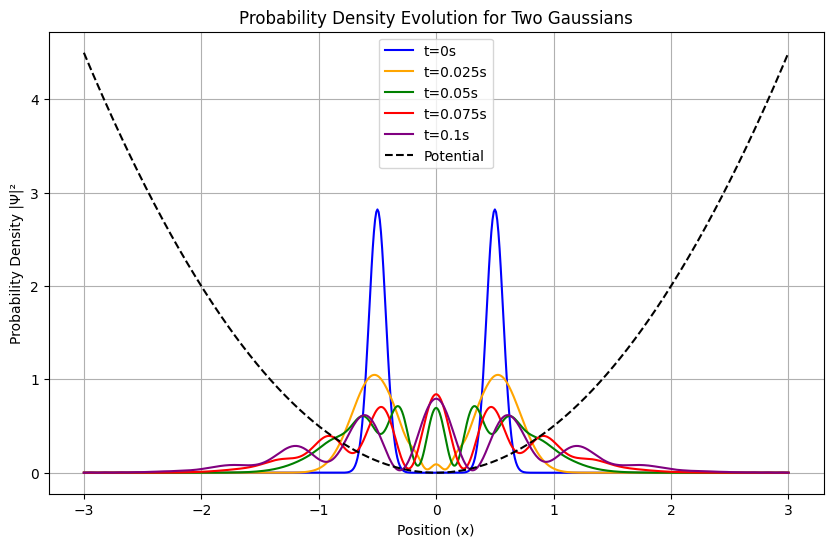

In [107]:
prob2 = solver2.calculate_probability_density(psi2)
norm2 = solver2.calculate_norm(psi2)
potential2 = solver2.potential(solver2.x)

plt.figure(figsize=(10, 6))
plt.plot(solver2.x, prob2[:, 0], label='t=0s', color='blue')
plt.plot(solver2.x, prob2[:, 25], label='t=0.025s', color='orange')
plt.plot(solver2.x, prob2[:, 50], label='t=0.05s', color='green')
plt.plot(solver2.x, prob2[:, 75], label='t=0.075s', color='red')
plt.plot(solver2.x, prob2[:, 99], label='t=0.1s', color='purple')
plt.plot(solver2.x, potential2, label='Potential', color='black', linestyle='--')

plt.title('Probability Density Evolution for Two Gaussians')
plt.xlabel('Position (x)')
plt.ylabel('Probability Density |Ψ|²')
plt.legend()
plt.grid()
plt.show()


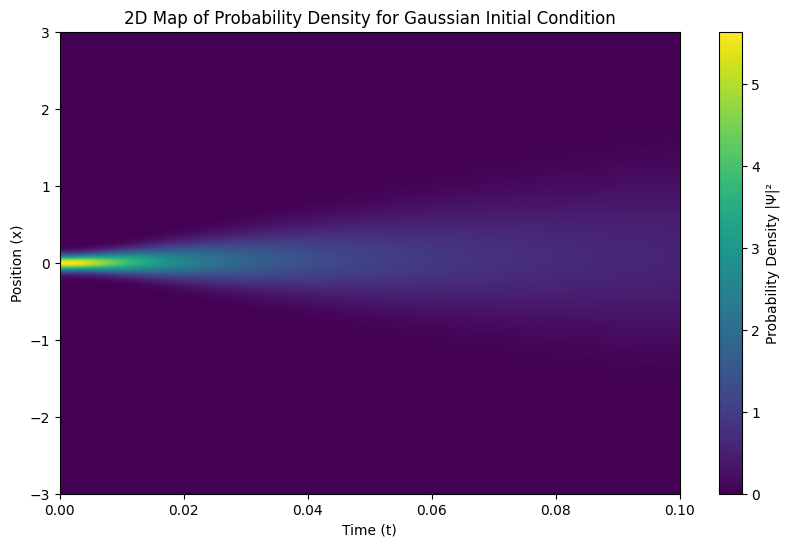

In [110]:
#2d map
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(psi1)**2, extent=[0, solver1.lt, -solver1.lx, solver1.lx], aspect='auto', origin='lower')
plt.colorbar(label='Probability Density |Ψ|²')
plt.title('2D Map of Probability Density for Gaussian Initial Condition')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.show()

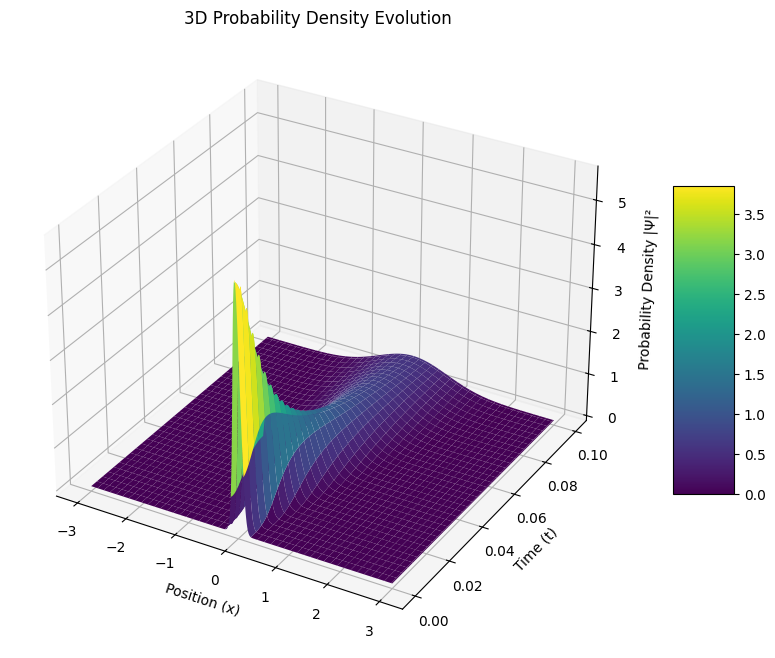

In [ ]:
#3d plot


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
X, T = np.meshgrid(solver1.x, solver1.t)
Z = prob.T
surf = ax.plot_surface(X, T, Z, cmap="viridis", edgecolor='none')
ax.set_xlabel('Position (x)')
ax.set_ylabel('Time (t)')

ax.set_zlabel('Probability Density |Ψ|²')
ax.set_title('3D Probability Density Evolution')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()


#### (d) Analysis:

- Compare the dynamics of the single Gaussian wave packet versus the superposition of two Gaussians. In particular, discuss what phenomena occur when the two Gaussian components of the superposition interact.

- Calculate and report the total probability (norm) $\sum_j |\Psi_j^{N_t}|^2 \Delta x$ at the final time step of each simulation. Compare it to the initial norm. Discuss if the Crank-Nicolson method conserves the norm, and why small deviations might still occur in practice.
